# HCMST Project — Clustering

## Goals
- load the cleaned Wave 1 ML-ready dataset
- define an interpretable clustering feature set
- scale features appropriately
- choose the number of clusters using elbow and silhouette methods
- fit a final K-Means clustering model
- profile and interpret the resulting clusters
- save clustering outputs for later reporting and modeling

## Why clustering is based on Wave 1 baseline profiles

The purpose of clustering here is to group respondents into broad relationship-profile categories based on their baseline situation at the beginning of the panel.

Wave 1 is the most appropriate source for clustering because:

- it has the largest sample size
- it contains the richest baseline relationship and demographic information
- later waves suffer from attrition
- using Wave 1 avoids defining clusters partly from later outcomes

For this reason, clustering is based on Wave 1 relationship-profile variables, while Wave 2 and Wave 3 variables are used later for follow-up interpretation and research questions.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUT_TABLES = OUTPUTS / "tables"
OUTPUT_FIGURES = OUTPUTS / "figures"

## Load the cleaned ML-ready dataset

This dataset was created in the cleaning notebook and contains numeric or already-recoded variables suitable for clustering.

In [5]:
df_ml = pd.read_csv(DATA_PROCESSED / "hcmst_wave1_ml_ready.csv")

print(df_ml.shape)
df_ml.head()

(2862, 13)


,caseid_new,w1_weight_combo,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w2_surveyed,w3_surveyed,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,w2_attrition_adj_weights,w3_attrition_adj_weight
0,53001.0,0.426861,48.0,1,1.0,0.0,1,1,0.0,3.583333,5.0,0.380351,0.400185
1,71609.0,1.295508,68.0,1,1.0,0.0,1,1,0.0,52.750000,5.0,0.953948,0.879258
2,106983.0,1.126573,39.0,0,1.0,0.0,1,1,0.0,17.583334,5.0,0.724682,0.706467
3,121759.0,0.933440,54.0,0,1.0,0.0,1,0,0.0,27.416666,5.0,0.793093,0.703767
4,164061.0,0.931291,59.0,0,1.0,0.0,1,1,0.0,23.583334,5.0,0.605404,0.342626


In [6]:
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 2862 entries, 0 to 2861
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   caseid_new                       2862 non-null   float64
 1   w1_weight_combo                  2862 non-null   float64
 2   w1_ppage                         2862 non-null   float64
 3   w1_ppgender_num                  2862 non-null   int64  
 4   w1_married                       2862 non-null   float64
 5   w1_q24_met_online                2862 non-null   float64
 6   w2_surveyed                      2862 non-null   int64  
 7   w3_surveyed                      2862 non-null   int64  
 8   w1_same_sex_couple_num           2862 non-null   float64
 9   w1_relate_duration_in2017_years  2862 non-null   float64
 10  w1_q34_score                     2862 non-null   float64
 11  w2_attrition_adj_weights         2862 non-null   float64
 12  w3_attrition_adj_weight        

In [7]:
df_ml.isna().sum()

caseid_new                         0
w1_weight_combo                    0
w1_ppage                           0
w1_ppgender_num                    0
w1_married                         0
w1_q24_met_online                  0
w2_surveyed                        0
w3_surveyed                        0
w1_same_sex_couple_num             0
w1_relate_duration_in2017_years    0
w1_q34_score                       0
w2_attrition_adj_weights           0
w3_attrition_adj_weight            0
dtype: int64

## Note on survey weights

The HCMST dataset includes survey weights because the public file is designed to be nationally representative after weighting, and because LGB respondents were intentionally oversampled.

In this clustering analysis, the weights are not used directly inside the K-Means or hierarchical clustering algorithms. The reason is that standard clustering procedures in scikit-learn are distance-based methods and are typically estimated on the observed feature matrix itself.

However, the weights remain important for:

- descriptive summaries of the sample
- weighted interpretation of cluster prevalence
- later modelling when population-level inference is needed

This means the clusters should be interpreted as structure in the observed analytical sample, not automatically as population-representative relationship types.

## Note on panel attrition

The panel shrinks substantially across waves:

- Wave 1: 3510 respondents
- Wave 2: 2107 respondents
- Wave 3: 1722 respondents

This attrition matters because later-wave outcomes are only observed for a subset of the original sample. Respondents who remain in the panel may differ systematically from those who drop out.

As a result, later-wave relationship outcomes should be interpreted carefully, especially when comparing long-term survival or breakup patterns.

## Choosing clustering features

For clustering, we want variables that describe respondents' baseline relationship profiles in Wave 1.

We exclude:
- `caseid_new` because it is only an identifier
- survey weights because weights should be used for interpretation and descriptive summaries, not as clustering features

We keep a compact, interpretable feature set mixing:
- demographics
- relationship structure
- meeting context
- relationship duration
- relationship quality

In [8]:
cluster_features = [
    "w1_ppage",
    "w1_ppgender_num",
    "w1_married",
    "w1_q24_met_online",
    "w1_same_sex_couple_num",
    "w1_relate_duration_in2017_years",
    "w1_q34_score"
]

X = df_ml[cluster_features].copy()

print(X.shape)
X.head()

(2862, 7)


,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
0,48.0,1,1.0,0.0,0.0,3.583333,5.0
1,68.0,1,1.0,0.0,0.0,52.750000,5.0
2,39.0,0,1.0,0.0,0.0,17.583334,5.0
3,54.0,0,1.0,0.0,0.0,27.416666,5.0
4,59.0,0,1.0,0.0,0.0,23.583334,5.0


### Why these features were selected

This first clustering feature set is intentionally compact and interpretable.

It includes:

- `w1_ppage`: respondent age
- `w1_ppgender_num`: respondent gender
- `w1_married`: marital status
- `w1_q24_met_online`: whether the couple met online
- `w1_same_sex_couple_num`: same-sex couple indicator
- `w1_relate_duration_in2017_years`: relationship duration
- `w1_q34_score`: relationship quality score

Together, these variables describe:
- who the respondent is
- how the relationship is structured
- how the couple met
- how long the relationship has lasted
- how strong the relationship appears at baseline

In [9]:
X.describe()

,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
count,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000,2862.000000
mean,49.369322,0.504542,0.728512,0.114955,0.076171,21.435855,4.484277
std,16.241715,0.500067,0.444805,0.319023,0.265317,16.377631,0.744734
min,18.000000,0.000000,0.000000,0.000000,0.000000,-0.333333,1.000000
25%,35.000000,0.000000,0.000000,0.000000,0.000000,7.500000,4.000000
50%,51.000000,1.000000,1.000000,0.000000,0.000000,18.083334,5.000000
75%,62.000000,1.000000,1.000000,0.000000,0.000000,33.625001,5.000000
max,93.000000,1.000000,1.000000,1.000000,1.000000,75.166664,5.000000


In [10]:
for col in cluster_features:
    print("\n", col)
    print(X[col].value_counts(dropna=False).head(10))


 w1_ppage
w1_ppage
55.0    80
58.0    78
27.0    74
56.0    71
54.0    69
28.0    69
53.0    67
59.0    66
57.0    66
60.0    64
Name: count, dtype: int64

 w1_ppgender_num
w1_ppgender_num
1    1444
0    1418
Name: count, dtype: int64

 w1_married
w1_married
1.0    2085
0.0     777
Name: count, dtype: int64

 w1_q24_met_online
w1_q24_met_online
0.0    2533
1.0     329
Name: count, dtype: int64

 w1_same_sex_couple_num
w1_same_sex_couple_num
0.0    2644
1.0     218
Name: count, dtype: int64

 w1_relate_duration_in2017_years
w1_relate_duration_in2017_years
18.083334    106
0.250000      22
0.000000      21
0.583333      21
0.666667      19
0.083333      19
0.166667      17
0.333333      16
5.833333      13
1.083333      13
Name: count, dtype: int64

 w1_q34_score
w1_q34_score
5.0    1721
4.0     884
3.0     202
2.0      32
1.0      23
Name: count, dtype: int64


## Standardizing clustering features

K-Means clustering depends on Euclidean distance, so variables measured on different scales must be standardized.

Without scaling, variables like age and relationship duration would dominate the clustering simply because they have larger numeric ranges.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.0843237 ,  0.99095634,  0.61046038, -0.36039633, -0.28714253,
        -1.09024565,  0.69261434],
       [ 1.14728856,  0.99095634,  0.61046038, -0.36039633, -0.28714253,
         1.91234108,  0.69261434],
       [-0.63854921, -1.0091262 ,  0.61046038, -0.36039633, -0.28714253,
        -0.23527176,  0.69261434],
       [ 0.28515998, -1.0091262 ,  0.61046038, -0.36039633, -0.28714253,
         0.36524551,  0.69261434],
       [ 0.59306304, -1.0091262 ,  0.61046038, -0.36039633, -0.28714253,
         0.1311456 ,  0.69261434]])

In [12]:
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)

X_scaled_df.describe().round(2)

,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
count,2862.00,2862.00,2862.00,2862.00,2862.00,2862.00,2862.00
mean,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.93,-1.01,-1.64,-0.36,-0.29,-1.33,-4.68
25%,-0.88,-1.01,-1.64,-0.36,-0.29,-0.85,-0.65
50%,0.10,0.99,0.61,-0.36,-0.29,-0.20,0.69
75%,0.78,0.99,0.61,-0.36,-0.29,0.74,0.69
max,2.69,0.99,0.61,2.77,3.48,3.28,0.69


## Choosing the Number of Clusters

We evaluate multiple values of k using:

- Elbow method (within-cluster inertia)
- Silhouette score (cluster separation)

These diagnostics help identify the most interpretable and statistically useful cluster solution.

In [13]:
k_values = range(2, 11)

inertias = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    km.fit(X_scaled)
    inertias.append(km.inertia_)

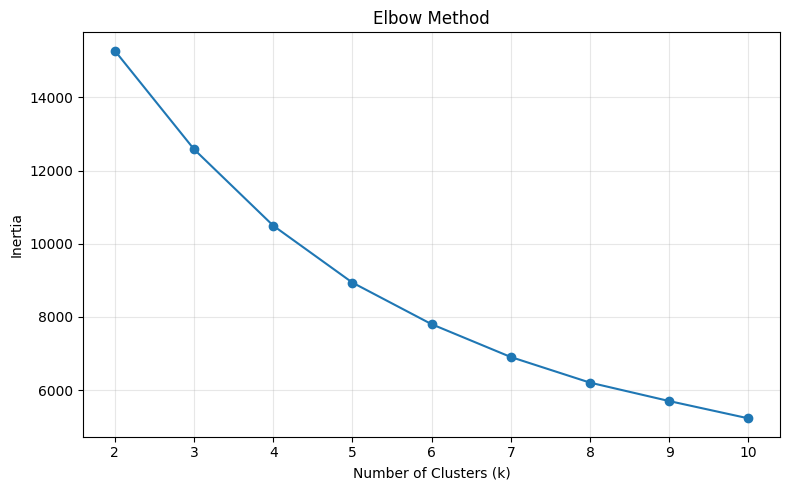

In [44]:
plt.figure(figsize=(8,5))
plt.plot(k_values, inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "kmeans_elbow_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
sil_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

In [16]:
results = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette": sil_scores
})

results

,k,inertia,silhouette
0,2,15275.099439,0.249532
1,3,12582.371396,0.268734
2,4,10494.179665,0.290504
3,5,8937.271400,0.278587
4,6,7800.749157,0.302346
5,7,6903.583354,0.316374
6,8,6203.542903,0.323158
7,9,5699.884159,0.332204
8,10,5227.133909,0.354609


In [43]:
results.to_csv(
    OUTPUT_TABLES / "kmeans_cluster_selection_metrics.csv",
    index=False
)

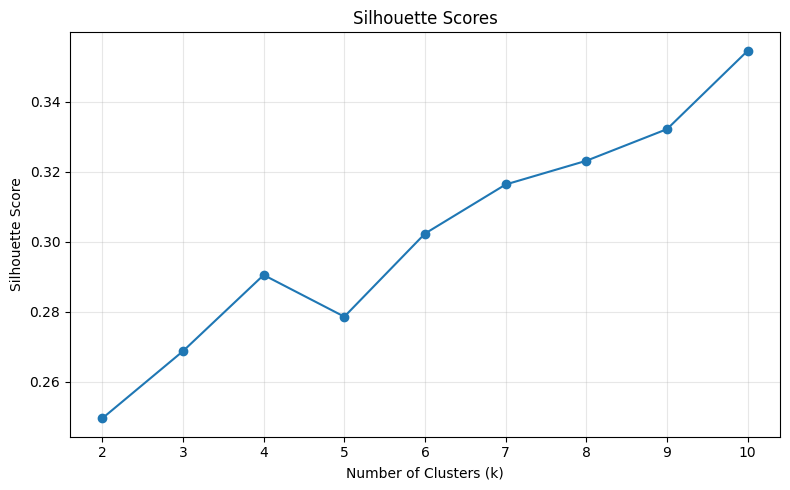

In [45]:
plt.figure(figsize=(8,5))
plt.plot(results["k"], results["silhouette"], marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "kmeans_silhouette_plot.png", dpi=300, bbox_inches="tight")
plt.show()

Although the highest silhouette score occurred at k=10, the elbow plot indicated diminishing returns after approximately k=6.

To balance statistical quality and interpretability, a six-cluster solution was selected for final modeling.

In [18]:
final_k = 6

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df_ml["cluster"] = clusters

df_ml["cluster"].value_counts().sort_index()

cluster
0    582
1    648
2    259
3    477
4    218
5    678
Name: count, dtype: int64

In [19]:
cluster_profile = df_ml.groupby("cluster")[cluster_features].mean().round(2)

cluster_profile

,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
cluster,,,,,,,
0,62.48,1.00,0.98,0.00,0.0,37.21,4.62
1,37.12,0.54,1.00,0.00,0.0,13.14,4.32
2,41.19,0.54,0.48,1.00,0.0,6.52,4.43
3,37.47,0.59,0.00,0.00,0.0,6.61,4.30
4,45.34,0.42,0.34,0.32,1.0,11.99,4.44
5,62.61,0.00,0.98,0.00,0.0,34.99,4.69


In [20]:
cluster_sizes = (
    df_ml["cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

cluster_sizes

cluster
0    20.3
1    22.6
2     9.0
3    16.7
4     7.6
5    23.7
Name: proportion, dtype: float64

In [21]:
profile = cluster_profile.copy()
profile["cluster_size_%"] = cluster_sizes

profile

,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster,,,,,,,,
0,62.48,1.00,0.98,0.00,0.0,37.21,4.62,20.3
1,37.12,0.54,1.00,0.00,0.0,13.14,4.32,22.6
2,41.19,0.54,0.48,1.00,0.0,6.52,4.43,9.0
3,37.47,0.59,0.00,0.00,0.0,6.61,4.30,16.7
4,45.34,0.42,0.34,0.32,1.0,11.99,4.44,7.6
5,62.61,0.00,0.98,0.00,0.0,34.99,4.69,23.7


In [46]:
profile_a = profile.copy()

profile_a.to_csv(
    OUTPUT_TABLES / "cluster_profile_kmeans_with_gender.csv"
)

# HCMSST Project — Final Cluster Interpretation (K-Means, k = 6)

## Overview

K-Means clustering was performed on standardized Wave 1 relationship variables using six clusters (`k = 6`).  

The selected features were:

- `w1_ppage` = respondent age  
- `w1_ppgender_num` = respondent gender  
- `w1_married` = marital status  
- `w1_q24_met_online` = whether couple met online  
- `w1_same_sex_couple_num` = same-sex couple indicator  
- `w1_relate_duration_in2017_years` = relationship duration in years  
- `w1_q34_score` = relationship quality score  

The six-cluster solution balanced interpretability with acceptable silhouette performance.

---

# Variable Decoding

## Binary Variables

### `w1_ppgender_num`

- `1 = Female`
- `0 = Male`

### `w1_married`

- `1 = Married`
- `0 = Not Married`

### `w1_q24_met_online`

- `1 = Met Online`
- `0 = Did Not Meet Online`

### `w1_same_sex_couple_num`

- `1 = Same-Sex Couple`
- `0 = Different-Sex Couple`

---

## Continuous Variables

### `w1_ppage`

Respondent age in years.

### `w1_relate_duration_in2017_years`

Length of relationship in years.

### `w1_q34_score`

Relationship quality score (higher values indicate better relationship quality).

---

# Final Cluster Profiles

| Cluster | Size % | Label |
|--------|-------|------|
| 0 | 20.3% | Older Married Women |
| 1 | 22.6% | Younger Married Couples |
| 2 | 9.0% | Online Newer Couples |
| 3 | 16.7% | Younger Unmarried Couples |
| 4 | 7.6% | Same-Sex Midlife Couples |
| 5 | 23.7% | Older Married Men |

---

# Detailed Cluster Interpretation

---

## Cluster 0 — Older Married Women

| Metric | Value |
|------|------|
| Mean Age | 62.48 |
| Gender | Female |
| Married | 98% |
| Met Online | 0% |
| Same-Sex Couple | 0% |
| Relationship Duration | 37.21 years |
| Relationship Quality | 4.62 |

### Interpretation

This cluster represents older female respondents in long-term marriages. These appear to be traditional, stable, long-duration unions formed largely offline.

---

## Cluster 1 — Younger Married Couples

| Metric | Value |
|------|------|
| Mean Age | 37.12 |
| Gender Mix | Balanced |
| Married | 100% |
| Met Online | 0% |
| Same-Sex Couple | 0% |
| Relationship Duration | 13.14 years |
| Relationship Quality | 4.32 |

### Interpretation

This segment reflects younger married couples in early-to-mid adulthood. Relationships are established but substantially shorter than older marriage clusters.

---

## Cluster 2 — Online Newer Couples

| Metric | Value |
|------|------|
| Mean Age | 41.19 |
| Gender Mix | Balanced |
| Married | 48% |
| Met Online | 100% |
| Same-Sex Couple | 0% |
| Relationship Duration | 6.52 years |
| Relationship Quality | 4.43 |

### Interpretation

This cluster captures modern couples who met online. Relationships are newer and marriage rates are lower, suggesting a more recent partnership formation pathway.

---

## Cluster 3 — Younger Unmarried Couples

| Metric | Value |
|------|------|
| Mean Age | 37.47 |
| Gender Mix | Balanced |
| Married | 0% |
| Met Online | 0% |
| Same-Sex Couple | 0% |
| Relationship Duration | 6.61 years |
| Relationship Quality | 4.30 |

### Interpretation

This segment includes younger couples in ongoing relationships who are not married. These may include dating, cohabiting, or long-term partnered respondents.

---

## Cluster 4 — Same-Sex Midlife Couples

| Metric | Value |
|------|------|
| Mean Age | 45.34 |
| Gender Mix | Mixed |
| Married | 34% |
| Met Online | 32% |
| Same-Sex Couple | 100% |
| Relationship Duration | 11.99 years |
| Relationship Quality | 4.44 |

### Interpretation

This cluster clearly identifies same-sex couples. Members are midlife respondents with moderate relationship duration and relatively high relationship quality.

---

## Cluster 5 — Older Married Men

| Metric | Value |
|------|------|
| Mean Age | 62.61 |
| Gender | Male |
| Married | 98% |
| Met Online | 0% |
| Same-Sex Couple | 0% |
| Relationship Duration | 34.99 years |
| Relationship Quality | 4.69 |

### Interpretation

This cluster mirrors Cluster 0 but consists primarily of older male respondents. It represents long-term traditional marriages with high reported relationship quality.

---

# Key Findings

## 1. Marriage Strongly Structures Clusters

Several clusters are separated by marital status:

- married couples
- unmarried couples
- mixed modern online couples

## 2. Online Meeting Creates a Distinct Relationship Type

Meeting online was strong enough to create a separate cluster.

## 3. Same-Sex Couples Form a Distinct Segment

Same-sex couples displayed unique demographic and structural characteristics.

## 4. Gender Split Appears Strong

Clusters 0 and 5 are highly similar except respondent gender, suggesting gender influenced segmentation.

---

# Overall Conclusion

The six-cluster K-Means solution reveals meaningful relationship profiles in the HCMSST Wave 1 sample:

- traditional long-term marriages  
- younger marriages  
- newer online couples  
- unmarried partnerships  
- same-sex couples  
- older male/female marriage segments  

These clusters provide a useful segmentation framework for later analysis of relationship outcomes, attrition, and satisfaction.

## B. Sensitivity analysis — clustering without gender

Because the first clustering solution partly separated respondents by gender, we run a second clustering specification without the gender variable.

The goal is to test whether the main relationship patterns remain similar when respondent sex is removed from the feature set.

This helps us evaluate whether the clusters are primarily driven by relationship structure and relationship history rather than by gender composition alone.

In [22]:
cluster_features_b = [
    "w1_ppage",
    "w1_married",
    "w1_q24_met_online",
    "w1_same_sex_couple_num",
    "w1_relate_duration_in2017_years",
    "w1_q34_score"
]

X_b = df_ml[cluster_features_b].copy()

print(X_b.shape)
X_b.head()

(2862, 6)


,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
0,48.0,1.0,0.0,0.0,3.583333,5.0
1,68.0,1.0,0.0,0.0,52.750000,5.0
2,39.0,1.0,0.0,0.0,17.583334,5.0
3,54.0,1.0,0.0,0.0,27.416666,5.0
4,59.0,1.0,0.0,0.0,23.583334,5.0


### Why this second feature set?

This version removes `w1_ppgender_num` from the clustering inputs.

The purpose is not to claim that gender is unimportant, but to check whether the cluster structure changes substantially when gender is excluded.

If the clusters remain broadly similar, then the original solution is robust.
If the clusters change a lot, then gender was playing a strong role in defining the first cluster solution.

In [23]:
scaler_b = StandardScaler()
X_b_scaled = scaler_b.fit_transform(X_b)

X_b_scaled_df = pd.DataFrame(X_b_scaled, columns=cluster_features_b)

X_b_scaled_df.describe().round(2)

,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
count,2862.00,2862.00,2862.00,2862.00,2862.00,2862.00
mean,-0.00,-0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.93,-1.64,-0.36,-0.29,-1.33,-4.68
25%,-0.88,-1.64,-0.36,-0.29,-0.85,-0.65
50%,0.10,0.61,-0.36,-0.29,-0.20,0.69
75%,0.78,0.61,-0.36,-0.29,0.74,0.69
max,2.69,0.61,2.77,3.48,3.28,0.69


### Choosing the number of clusters for the no-gender specification

We repeat the same model selection process used in Section A:
- elbow method
- silhouette score

This keeps the comparison fair across specifications.

In [24]:
k_values_b = range(2, 11)
inertias_b = []
sil_scores_b = []

for k in k_values_b:
    km_b = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels_b = km_b.fit_predict(X_b_scaled)
    inertias_b.append(km_b.inertia_)
    sil_scores_b.append(silhouette_score(X_b_scaled, labels_b))

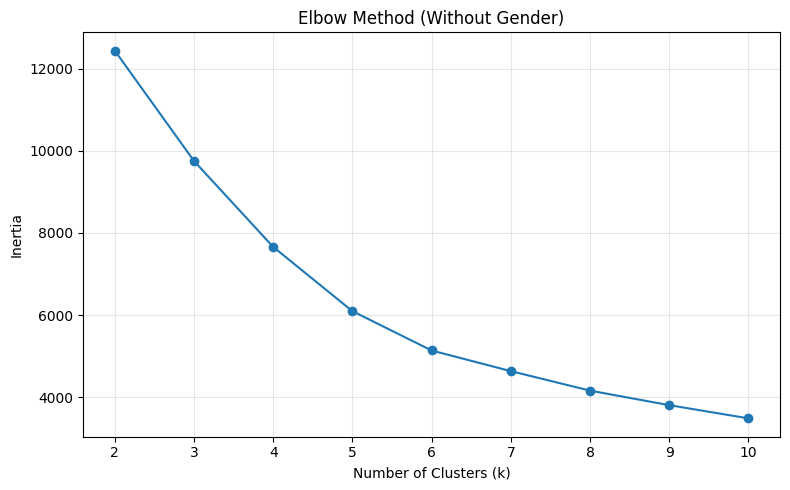

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values_b), inertias_b, marker="o")
plt.title("Elbow Method (Without Gender)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values_b))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "kmeans_no_gender_elbow_plot.png", dpi=300, bbox_inches="tight")
plt.show()

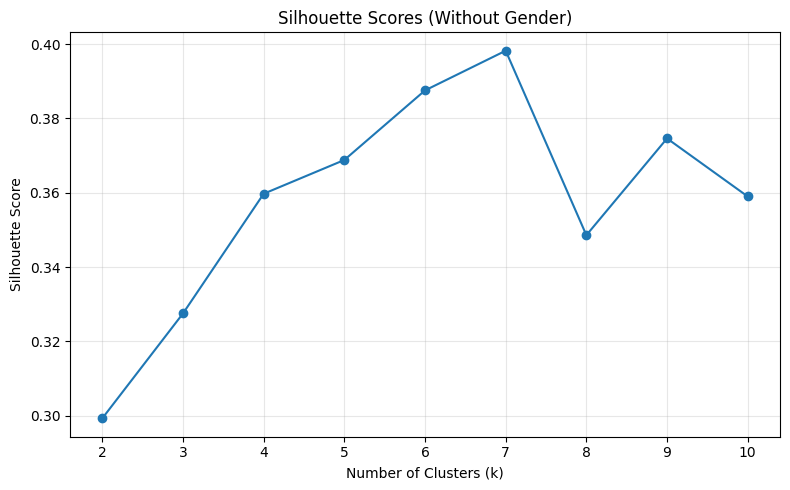

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values_b), sil_scores_b, marker="o")
plt.title("Silhouette Scores (Without Gender)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values_b))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "kmeans_no_gender_silhouette_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
results_b = pd.DataFrame({
    "k": list(k_values_b),
    "inertia": inertias_b,
    "silhouette": sil_scores_b
})

results_b

,k,inertia,silhouette
0,2,12433.230490,0.299330
1,3,9750.682917,0.327540
2,4,7660.279747,0.359735
3,5,6098.451668,0.368821
4,6,5141.776116,0.387535
5,7,4639.575280,0.398211
6,8,4165.833752,0.348594
7,9,3812.027683,0.374614
8,10,3490.983865,0.359006


In [47]:
results_b.to_csv(
    OUTPUT_TABLES / "kmeans_no_gender_cluster_selection_metrics.csv",
    index=False
)

### Choosing the final number of clusters

To make the comparison with Section A straightforward, we retain a six-cluster solution here as well, unless the diagnostics strongly suggest otherwise.

Using the same `k` allows us to compare whether the interpretation of the clusters changes when gender is removed.

In [28]:
final_k_b = 6

kmeans_b = KMeans(
    n_clusters=final_k_b,
    random_state=42,
    n_init=20
)

clusters_b = kmeans_b.fit_predict(X_b_scaled)

df_ml["cluster_b"] = clusters_b

df_ml["cluster_b"].value_counts().sort_index()

cluster_b
0    256
1    800
2    465
3    218
4    161
5    962
Name: count, dtype: int64

In [29]:
cluster_profile_b = df_ml.groupby("cluster_b")[cluster_features_b].mean().round(2)
cluster_profile_b

,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score
cluster_b,,,,,,
0,41.35,0.48,1.00,0.0,6.58,4.46
1,41.06,1.00,0.00,0.0,15.48,4.66
2,37.46,0.00,0.00,0.0,6.59,4.37
3,45.34,0.34,0.32,1.0,11.99,4.44
4,48.07,0.89,0.02,0.0,20.62,2.55
5,65.30,0.98,0.00,0.0,39.80,4.73


In [30]:
cluster_sizes_b = (
    df_ml["cluster_b"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

profile_b = cluster_profile_b.copy()
profile_b["cluster_size_%"] = cluster_sizes_b

profile_b

,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster_b,,,,,,,
0,41.35,0.48,1.00,0.0,6.58,4.46,8.9
1,41.06,1.00,0.00,0.0,15.48,4.66,28.0
2,37.46,0.00,0.00,0.0,6.59,4.37,16.2
3,45.34,0.34,0.32,1.0,11.99,4.44,7.6
4,48.07,0.89,0.02,0.0,20.62,2.55,5.6
5,65.30,0.98,0.00,0.0,39.80,4.73,33.6


In [50]:
profile_b.to_csv(
    OUTPUT_TABLES / "cluster_profile_kmeans_without_gender.csv"
)

### Comparing the two specifications

We now compare the original clustering solution (with gender) to the alternative solution (without gender).

The main question is whether the clusters remain centered on:
- age
- marriage status
- online meeting
- same-sex couple status
- relationship duration
- relationship quality

If so, then the overall findings are robust.

In [31]:
print("Section A features:", cluster_features)
print("Section B features:", cluster_features_b)

print("\nSection A profile:")
display(profile)

print("\nSection B profile:")
display(profile_b)

Section A features: ['w1_ppage', 'w1_ppgender_num', 'w1_married', 'w1_q24_met_online', 'w1_same_sex_couple_num', 'w1_relate_duration_in2017_years', 'w1_q34_score']
Section B features: ['w1_ppage', 'w1_married', 'w1_q24_met_online', 'w1_same_sex_couple_num', 'w1_relate_duration_in2017_years', 'w1_q34_score']

Section A profile:


,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster,,,,,,,,
0,62.48,1.00,0.98,0.00,0.0,37.21,4.62,20.3
1,37.12,0.54,1.00,0.00,0.0,13.14,4.32,22.6
2,41.19,0.54,0.48,1.00,0.0,6.52,4.43,9.0
3,37.47,0.59,0.00,0.00,0.0,6.61,4.30,16.7
4,45.34,0.42,0.34,0.32,1.0,11.99,4.44,7.6
5,62.61,0.00,0.98,0.00,0.0,34.99,4.69,23.7



Section B profile:


,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster_b,,,,,,,
0,41.35,0.48,1.00,0.0,6.58,4.46,8.9
1,41.06,1.00,0.00,0.0,15.48,4.66,28.0
2,37.46,0.00,0.00,0.0,6.59,4.37,16.2
3,45.34,0.34,0.32,1.0,11.99,4.44,7.6
4,48.07,0.89,0.02,0.0,20.62,2.55,5.6
5,65.30,0.98,0.00,0.0,39.80,4.73,33.6


In [32]:
profile_a = profile.copy()

In [33]:
print("\nSection A profile:")
display(profile_a)

print("\nSection B profile:")
display(profile_b)


Section A profile:


,w1_ppage,w1_ppgender_num,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster,,,,,,,,
0,62.48,1.00,0.98,0.00,0.0,37.21,4.62,20.3
1,37.12,0.54,1.00,0.00,0.0,13.14,4.32,22.6
2,41.19,0.54,0.48,1.00,0.0,6.52,4.43,9.0
3,37.47,0.59,0.00,0.00,0.0,6.61,4.30,16.7
4,45.34,0.42,0.34,0.32,1.0,11.99,4.44,7.6
5,62.61,0.00,0.98,0.00,0.0,34.99,4.69,23.7



Section B profile:


,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster_b,,,,,,,
0,41.35,0.48,1.00,0.0,6.58,4.46,8.9
1,41.06,1.00,0.00,0.0,15.48,4.66,28.0
2,37.46,0.00,0.00,0.0,6.59,4.37,16.2
3,45.34,0.34,0.32,1.0,11.99,4.44,7.6
4,48.07,0.89,0.02,0.0,20.62,2.55,5.6
5,65.30,0.98,0.00,0.0,39.80,4.73,33.6


## Comparing the Two Specifications

Two K-Means clustering specifications were estimated:

### Section A — Original Model
Included:

- age
- gender
- marital status
- online meeting status
- same-sex couple indicator
- relationship duration
- relationship quality

### Section B — Alternative Model
Excluded respondent gender (`w1_ppgender_num`) to test whether the cluster structure remained similar when gender was removed.

---

# Main Comparison Findings

## 1. Gender-Based Separation Disappeared

In Section A, two clusters were highly similar except for respondent gender:

- Cluster 0 = older married women  
- Cluster 5 = older married men  

After removing gender in Section B, these two clusters largely merged into one broader older married long-duration group:

- **Cluster B5**
- Mean age = 65.3
- Married = 98%
- Duration = 39.8 years
- Highest relationship quality = 4.73
- Largest cluster = 33.6%

### Interpretation

This confirms that respondent gender was driving some of the separation in the original model.

---

## 2. Marriage Remains a Strong Structuring Force

Even without gender, married respondents still formed clear clusters:

### Cluster B1

- Age = 41.1
- Married = 100%
- Duration = 15.5 years
- Quality = 4.66
- Size = 28.0%

### Cluster B5

- Older long-term marriages
- Size = 33.6%

### Interpretation

Marriage status and relationship duration remain powerful drivers of clustering independent of gender.

---

## 3. Online Couples Remain Distinct

### Cluster B0

- Met online = 100%
- Married = 48%
- Duration = 6.6 years
- Quality = 4.46
- Size = 8.9%

### Interpretation

Couples who met online continue to form a clearly separate relationship segment, even after gender is removed.

This suggests online meeting context is a meaningful relationship characteristic.

---

## 4. Same-Sex Couples Remain Distinct

### Cluster B3

- Same-sex couple = 100%
- Married = 34%
- Duration = 12.0 years
- Quality = 4.44
- Size = 7.6%

### Interpretation

Same-sex couples continue to cluster together in the no-gender specification, indicating a robust structural subgroup.

---

## 5. Younger Unmarried Couples Still Appear

### Cluster B2

- Age = 37.5
- Married = 0%
- Duration = 6.6 years
- Quality = 4.37
- Size = 16.2%

### Interpretation

This cluster reflects younger partnered respondents who are not married, similar to the unmarried cluster in Section A.

---

## 6. One Lower-Quality Midlife Married Cluster Emerged

### Cluster B4

- Age = 48.1
- Married = 89%
- Duration = 20.6 years
- Relationship quality = **2.55**
- Size = 5.6%

### Interpretation

This is an important new cluster that did not appear clearly in Section A.

It suggests that after removing gender, the algorithm identified a subgroup of midlife marriages with notably lower relationship satisfaction.

This may represent strained or vulnerable long-term relationships.

---

# Overall Interpretation

The Section B results are more sociologically meaningful than Section A because they emphasize:

- relationship duration
- marital status
- meeting context
- same-sex couple structure
- relationship quality

rather than respondent gender.

Removing gender allowed the model to uncover a new low-quality marriage cluster and combine redundant male/female long-marriage clusters.

---

# Final Conclusion

Both specifications are informative:

## Section A

Useful for showing that gender influences relationship clustering.

## Section B

Preferred for substantive interpretation because it highlights relationship types rather than respondent sex differences.

For final reporting, Section B is the stronger clustering solution, while Section A serves as a robustness check.

In [34]:
cluster_features_b = [
    "w1_ppage",
    "w1_married",
    "w1_q24_met_online",
    "w1_same_sex_couple_num",
    "w1_relate_duration_in2017_years",
    "w1_q34_score"
]

In [35]:
X_b_scaled

array([[-0.0843237 ,  0.61046038, -0.36039633, -0.28714253, -1.09024565,
         0.69261434],
       [ 1.14728856,  0.61046038, -0.36039633, -0.28714253,  1.91234108,
         0.69261434],
       [-0.63854921,  0.61046038, -0.36039633, -0.28714253, -0.23527176,
         0.69261434],
       ...,
       [-1.62383902, -1.63810796, -0.36039633, -0.28714253, -1.25818694,
         0.69261434],
       [-0.94645228, -1.63810796, -0.36039633,  3.48259104, -1.1665826 ,
        -0.65038176],
       [-1.74700024, -1.63810796, -0.36039633,  3.48259104, -1.30907824,
         0.69261434]], shape=(2862, 6))

# Section C — Hierarchical Clustering

To complement the K-Means results, we estimate a hierarchical clustering model using the same no-gender feature set from Section B.

Hierarchical clustering allows us to visualize how respondents group together step-by-step through a dendrogram and provides an alternative segmentation method.

This serves as a robustness check for the K-Means findings.

In [36]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [37]:
Z = linkage(X_b_scaled, method="ward")

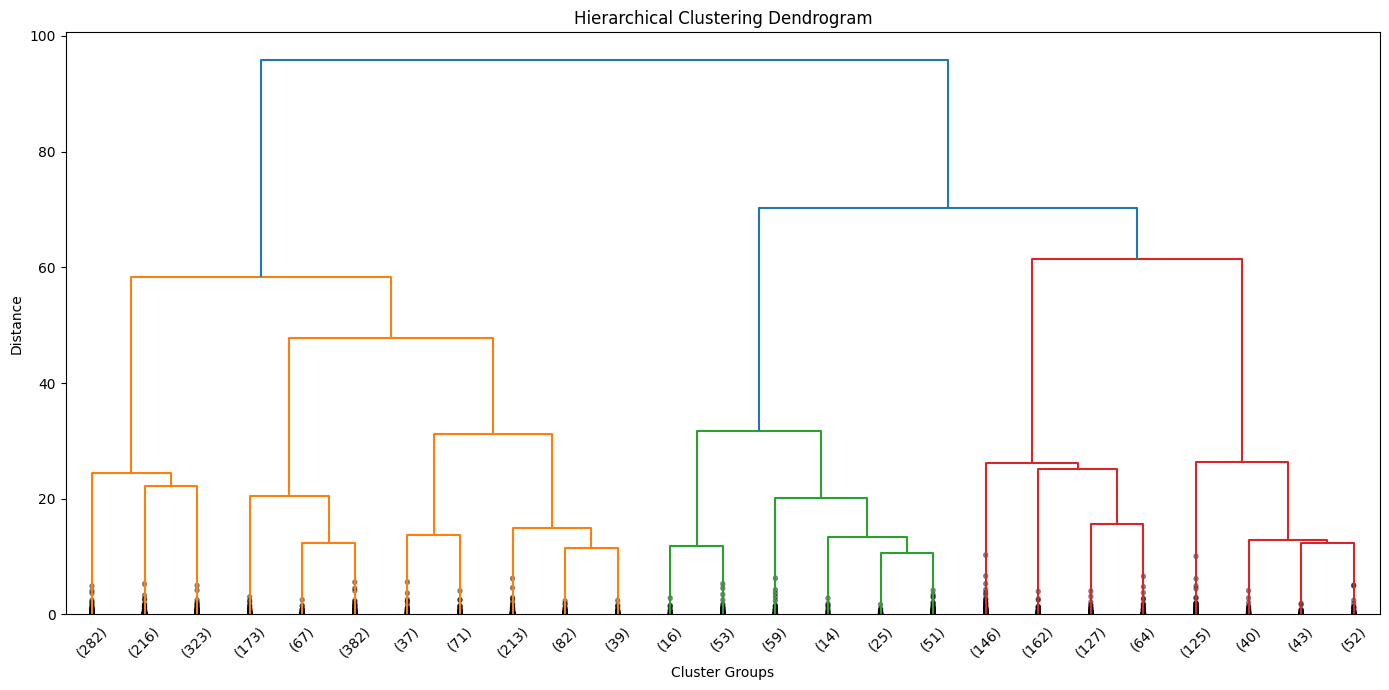

In [51]:
plt.figure(figsize=(14,7))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=45,
    leaf_font_size=10,
    show_contracted=True
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES / "hierarchical_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
df_ml["cluster_h"] = fcluster(Z, 6, criterion="maxclust")

In [40]:
df_ml["cluster_h"].value_counts().sort_index()

cluster_h
1    821
2    622
3    442
4    218
5    499
6    260
Name: count, dtype: int64

In [41]:
cluster_profile_h = df_ml.groupby("cluster_h")[cluster_features_b].mean().round(2)

cluster_sizes_h = (
    df_ml["cluster_h"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

profile_h = cluster_profile_h.copy()
profile_h["cluster_size_%"] = cluster_sizes_h

profile_h

,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster_h,,,,,,,
1,41.61,1.00,0.00,0.0,16.01,4.74,28.7
2,66.62,1.00,0.00,0.0,41.53,5.00,21.7
3,58.08,1.00,0.00,0.0,31.88,3.55,15.4
4,45.34,0.34,0.32,1.0,11.99,4.44,7.6
5,38.88,0.00,0.00,0.0,7.89,4.30,17.4
6,41.32,0.48,1.00,0.0,6.66,4.43,9.1


In [52]:
profile_h.to_csv(
    OUTPUT_TABLES / "cluster_profile_hierarchical.csv"
)

In [42]:
print("Section B (KMeans without gender)")
display(profile_b)

print("Section C (Hierarchical)")
display(profile_h)

Section B (KMeans without gender)


,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster_b,,,,,,,
0,41.35,0.48,1.00,0.0,6.58,4.46,8.9
1,41.06,1.00,0.00,0.0,15.48,4.66,28.0
2,37.46,0.00,0.00,0.0,6.59,4.37,16.2
3,45.34,0.34,0.32,1.0,11.99,4.44,7.6
4,48.07,0.89,0.02,0.0,20.62,2.55,5.6
5,65.30,0.98,0.00,0.0,39.80,4.73,33.6


Section C (Hierarchical)


,w1_ppage,w1_married,w1_q24_met_online,w1_same_sex_couple_num,w1_relate_duration_in2017_years,w1_q34_score,cluster_size_%
cluster_h,,,,,,,
1,41.61,1.00,0.00,0.0,16.01,4.74,28.7
2,66.62,1.00,0.00,0.0,41.53,5.00,21.7
3,58.08,1.00,0.00,0.0,31.88,3.55,15.4
4,45.34,0.34,0.32,1.0,11.99,4.44,7.6
5,38.88,0.00,0.00,0.0,7.89,4.30,17.4
6,41.32,0.48,1.00,0.0,6.66,4.43,9.1


# Section C Results — Hierarchical Clustering

## Overview

Hierarchical clustering was estimated using the same feature set as Section B:

- respondent age (`w1_ppage`)
- marital status (`w1_married`)
- met online (`w1_q24_met_online`)
- same-sex couple (`w1_same_sex_couple_num`)
- relationship duration (`w1_relate_duration_in2017_years`)
- relationship quality (`w1_q34_score`)

Ward linkage was used on standardized features.

A six-cluster solution was selected to match the preferred K-Means specification from Section B.

---

## Dendrogram Interpretation

The dendrogram showed several large jumps in merge distance, indicating meaningful natural groupings in the sample.

The six-cluster cut provides a balanced level of segmentation:

- enough clusters to capture meaningful relationship types
- still interpretable for substantive analysis

---

## Hierarchical Cluster Profiles

### Cluster H1 — Midlife Married Couples (28.7%)

- Mean age: 41.6
- 100% married
- Average duration: 16.0 years
- Very high relationship quality (4.74)

This appears to be a broad stable married midlife group.

---

### Cluster H2 — Older Long-Term Marriages (21.7%)

- Mean age: 66.6
- 100% married
- Longest duration: 41.5 years
- Highest relationship quality (5.00)

This cluster represents older, highly stable long-duration marriages.

---

### Cluster H3 — Older Married Couples with Lower Quality (15.4%)

- Mean age: 58.1
- 100% married
- Duration: 31.9 years
- Lower quality score (3.55)

This suggests older established marriages with lower relationship satisfaction.

---

### Cluster H4 — Same-Sex Couples (7.6%)

- Mean age: 45.3
- 34% married
- 32% met online
- 100% same-sex couples
- Duration: 12.0 years
- Quality: 4.44

This clearly isolates same-sex relationships as a distinct relationship segment.

---

### Cluster H5 — Younger Unmarried Couples (17.4%)

- Mean age: 38.9
- 0% married
- Duration: 7.9 years
- Quality: 4.30

This cluster captures younger cohabiting or dating couples.

---

### Cluster H6 — Online-Meeting Couples (9.1%)

- Mean age: 41.3
- 48% married
- 100% met online
- Duration: 6.7 years
- Quality: 4.43

This segment represents digitally formed relationships.

---

# Comparing Section B (K-Means) vs Section C (Hierarchical)

Both methods identified nearly identical relationship structures:

- older long-term marriages
- younger unmarried couples
- online-formed couples
- same-sex couples
- lower-quality older marriages
- stable midlife marriages

This consistency strongly increases confidence that the segments reflect genuine patterns in the population rather than assumptions of a single clustering method.

---

# Final Conclusion

Across two different unsupervised learning methods, the HCMST data consistently reveals multiple distinct relationship types structured by:

- life stage
- marriage status
- relationship duration
- meeting context
- sexual orientation
- relationship quality

These findings suggest that romantic relationships in the United States are highly heterogeneous and can be meaningfully segmented using survey data.

## Final clustering conclusion

Across the clustering exercises, the HCMST data consistently reveals several broad relationship types in the Wave 1 active-relationship sample.

The most stable patterns across specifications are:

- older long-term married couples
- younger unmarried couples
- online-formed couples
- same-sex couples
- midlife or mixed married groups with moderate-to-high relationship quality

The exact boundaries shift slightly across specifications, but the overall segmentation is robust. This suggests that the clusters are not purely mathematical artefacts; they correspond to meaningful sociological differences in age, marriage status, relationship duration, meeting context, and relationship structure.

For the rest of the project, these clusters can be used as an exploratory lens for understanding how different relationship types may evolve over time.

In [53]:
df_ml.to_csv(
    DATA_PROCESSED / "hcmst_wave1_ml_with_clusters.csv",
    index=False
)